Epoch   0 | Loss: 0.680837
Epoch  10 | Loss: 0.084456
Epoch  20 | Loss: 0.062364
Epoch  30 | Loss: 0.052607
Epoch  40 | Loss: 0.047806
Epoch  50 | Loss: 0.056243
Epoch  60 | Loss: 0.033860
Epoch  70 | Loss: 0.032969
Epoch  80 | Loss: 0.027266
Epoch  90 | Loss: 0.024295
Epoch 100 | Loss: 0.020080
Epoch 110 | Loss: 0.015804
Epoch 120 | Loss: 0.013948
Epoch 130 | Loss: 0.017586
Epoch 140 | Loss: 0.010106
Epoch 150 | Loss: 0.017097
Epoch 160 | Loss: 0.018159
Epoch 170 | Loss: 0.006294
Epoch 180 | Loss: 0.005926
Epoch 190 | Loss: 0.006982

Test RMSE: 0.0525, R²: 0.9676


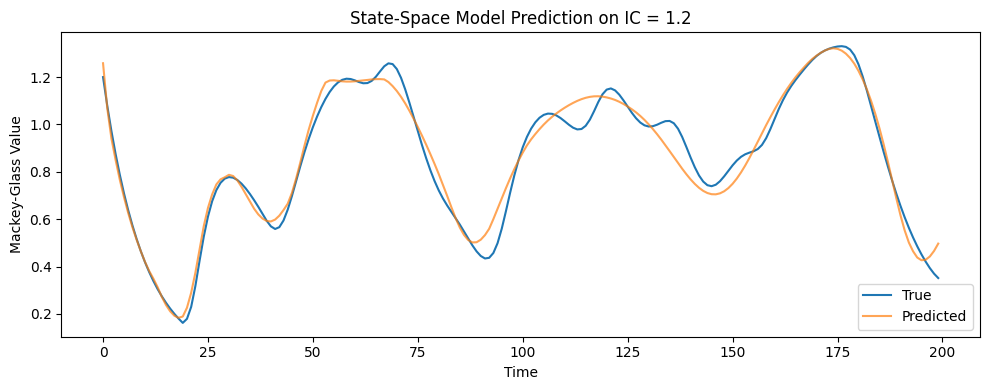

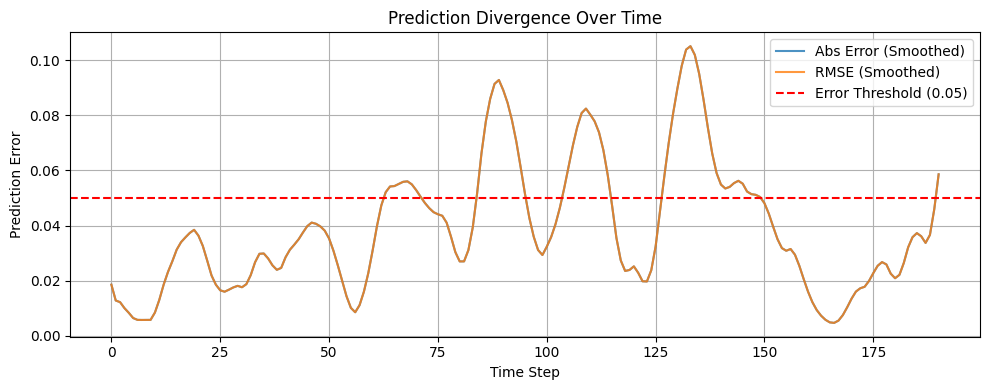

Prediction horizon at threshold 0.05: 73 steps

F-statistic: 2942.4010
P-value: 1.1102e-16


In [3]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import f

# === Mackey-Glass Generator ===
def generate_mg_series(x0, t_max=200, delta_t=1, tau=20, beta=0.2, gamma=0.1, n=10):
    t_len = int(t_max / delta_t)
    x = np.zeros(t_len)
    x[0] = x0
    for t in range(1, t_len):
        if t - tau >= 0:
            x[t] = x[t - 1] + delta_t * (
                beta * x[t - tau] / (1 + x[t - tau] ** n) - gamma * x[t - 1]
            )
        else:
            x[t] = x[t - 1] - delta_t * gamma * x[t - 1]
    return x

# === Dataset Generation ===
t_max = 200
timesteps = t_max
ics_train = np.concatenate((np.linspace(0, 1.19, 20), np.linspace(1.21, 3, 20)))
ic_test = 1.2

X_train = []
y_train = []

for ic in ics_train:
    series = generate_mg_series(ic, t_max=t_max)
    norm_time = np.linspace(0, 1, timesteps)
    inputs = np.stack([np.full(timesteps, ic), norm_time], axis=1)
    X_train.append(inputs)
    y_train.append(series)

X_train = np.array(X_train)  # shape: (20, 200, 2)
y_train = np.array(y_train)  # shape: (20, 200)

# Test sequence
test_series = generate_mg_series(ic_test, t_max=t_max)
X_test = np.stack([np.full(timesteps, ic_test), np.linspace(0, 1, timesteps)], axis=1)
y_test = test_series

# === Normalization ===
scaler = StandardScaler()
X_train_flat = X_train.reshape(-1, 2)
X_train_scaled = scaler.fit_transform(X_train_flat).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test)

# === Torch Data ===
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)  # (20, 200, 2)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)         # (20, 200)

train_ds = TensorDataset(X_train_tensor, y_train_tensor)
train_dl = DataLoader(train_ds, batch_size=4, shuffle=True)

# === State-Space Model ===
class StateSpaceModel(nn.Module):
    def __init__(self, input_dim=2, latent_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim),
        )
        self.dynamics = nn.GRU(latent_dim, latent_dim, batch_first=True)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        latent = self.encoder(x)  # (B, T, latent_dim)
        out, _ = self.dynamics(latent)  # (B, T, latent_dim)
        pred = self.decoder(out).squeeze(-1)  # (B, T)
        return pred

# === Train Function ===
def train_model(model, dataloader, epochs=200, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        for xb, yb in dataloader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d} | Loss: {total_loss / len(dataloader):.6f}")

# === Training ===
model = StateSpaceModel()
train_model(model, train_dl, epochs=200)

# === Testing ===
model.eval()
X_test_tensor = torch.tensor(X_test_scaled[None, ...], dtype=torch.float32)  # (1, 200, 2)
with torch.no_grad():
    y_pred = model(X_test_tensor).squeeze().numpy()

# === Evaluation ===
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"\nTest RMSE: {rmse:.4f}, R²: {r2:.4f}")

# === Plot ===
plt.figure(figsize=(10, 4))
plt.plot(y_test, label="True")
plt.plot(y_pred, label="Predicted", alpha=0.7)
plt.title(f"State-Space Model Prediction on IC = {ic_test}")
plt.xlabel("Time")
plt.ylabel("Mackey-Glass Value")
plt.legend()
plt.tight_layout()
plt.show()

# Divergence
errors = np.abs(y_pred - y_test)            # abs error
rmse_window = np.sqrt((y_pred - y_test)**2) # RMSE error

# Optional: smooth with moving average for clarity
def moving_avg(x, w=10):
    return np.convolve(x, np.ones(w)/w, mode='valid')

window_size = 10
smoothed_error = moving_avg(errors, w=window_size)
smoothed_rmse = moving_avg(rmse_window, w=window_size)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(smoothed_error, label="Abs Error (Smoothed)", alpha=0.8)
plt.plot(smoothed_rmse, label="RMSE (Smoothed)", alpha=0.8)
plt.axhline(y=0.05, color='r', linestyle='--', label='Error Threshold (0.05)')
plt.title("Prediction Divergence Over Time")
plt.xlabel("Time Step")
plt.ylabel("Prediction Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

threshold = 0.05
divergence_time = np.argmax(smoothed_error > threshold) + window_size
print(f"Prediction horizon at threshold {threshold}: {divergence_time} steps")

# --- F-test calculation ---
n = len(y_pred)  # Number of samples after washout
k = X_test.shape[1]        # Number of input features (2 in this case: ic and t)

F = (r2 / k) / ((1 - r2) / (n - k - 1))
p_value = 1 - f.cdf(F, k, n - k - 1)

print(f"\nF-statistic: {F:.4f}")
print(f"P-value: {p_value:.4e}")